In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('spam.csv', encoding = 'latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(columns = {'Unnamed: 2','Unnamed: 3', 'Unnamed: 4'}, axis = 1, inplace = True)

In [5]:
df.rename(columns = {'v1':'label', 'v2' : 'email'},inplace = True)

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
y = df['label']
y = le.fit_transform(y)

In [8]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [9]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

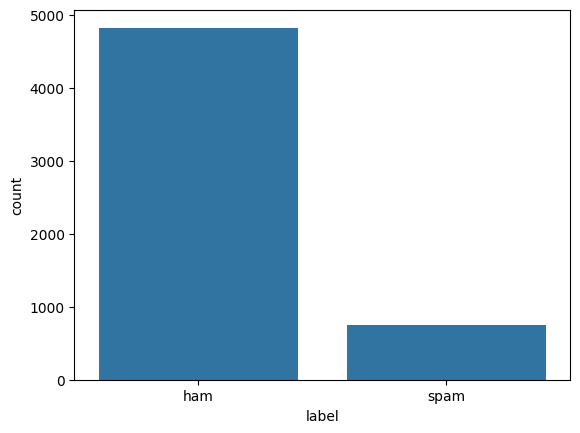

In [10]:
sns.barplot(df['label'] .value_counts())

# Text cleaning

In [11]:
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string 
from bs4 import BeautifulSoup
import re

lowercasing  
html parser   
br tags   
removing urls  
remove punctuation  
remove stopwords  
stemming / lemmatization 

In [12]:
stp = stopwords.words('english')

In [13]:
stp[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [14]:
def cleanup(text):
    text = text.lower()

    soup = BeautifulSoup(text, 'html.parser')
    text = soup.get_text(separator = ' ')

    text = re.sub(r'[^a-zA-Z0-9\s]','', text)


    lem = WordNetLemmatizer()
    text = ' '.join([lem.lemmatize (w) for w in text.split()])
    

    text = ' '.join([w for w  in text.split() if w not in stp])
    
    # text = text.translate(str.maketrans('','',string.punctuation))
    return text  
    
    

In [15]:
df['email'].apply(cleanup)

0       go jurong point crazy available bugis n great ...
1                                 ok lar joking wif u oni
2       free entry 2 wkly comp win fa cup final tkts 2...
3                     u dun say early hor u c already say
4                nah dont think go usf life around though
                              ...                        
5567    2nd time tried 2 contact u u 750 pound prize 2...
5568                            b going esplanade fr home
5569                        pity wa mood soany suggestion
5570    guy bitching acted like id interested buying s...
5571                                       rofl true name
Name: email, Length: 5572, dtype: object

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


In [17]:
tfidf = TfidfVectorizer()

In [18]:
X = df['email']

In [19]:
X_train_raw,X_test_raw,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 59)

In [20]:
X_train_vec = tfidf.fit_transform(X_train_raw)
X_test_vec = tfidf.transform(X_test_raw)

In [21]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score,f1_score, roc_auc_score,precision_score,recall_score, roc_curve

In [22]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(random_state=59)
}

In [25]:
def training(models,X_train,X_test,y_train,y_test):
    results = []
    saved_model = {}
    import time
    for name,model in models.items():
        
        start= time.time()
        model.fit(X_train,y_train)
        pred = model.predict(X_test)
        
        ac = accuracy_score(y_test,pred)
        f1 = f1_score(y_test,pred)
        end = time.time()

        results.append({
            'Model':name,
            'Accuracy':ac,
            'F1_score':f1,
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            'Training_time':end-start
        })
        saved_model[name] = model
    return results ,saved_model

In [26]:
result,saved_models= training(models,X_train_vec,X_test_vec,y_train,y_test)

In [27]:
import pprint
pprint.pprint(result)

[{'Accuracy': 0.9641255605381166,
  'F1_score': 0.8319327731092437,
  'Model': 'Naive Bayes',
  'Precision': 1.0,
  'Recall': 0.7122302158273381,
  'Training_time': 0.004876136779785156},
 {'Accuracy': 0.9766816143497757,
  'F1_score': 0.8984375,
  'Model': 'Logistic Regression',
  'Precision': 0.9829059829059829,
  'Recall': 0.8273381294964028,
  'Training_time': 0.014959096908569336},
 {'Accuracy': 0.9901345291479821,
  'F1_score': 0.9597069597069597,
  'Model': 'Linear SVM',
  'Precision': 0.9776119402985075,
  'Recall': 0.9424460431654677,
  'Training_time': 0.009389400482177734},
 {'Accuracy': 0.9820627802690582,
  'F1_score': 0.9224806201550387,
  'Model': 'Random Forest',
  'Precision': 1.0,
  'Recall': 0.8561151079136691,
  'Training_time': 0.8555536270141602}]


In [28]:
result = pd.DataFrame(result)
result= result.sort_values('Accuracy',ascending=False)


In [29]:
result

,Model,Accuracy,F1_score,Precision,Recall,Training_time
2,Linear SVM,0.990135,0.959707,0.977612,0.942446,0.009389
3,Random Forest,0.982063,0.922481,1.000000,0.856115,0.855554
1,Logistic Regression,0.976682,0.898438,0.982906,0.827338,0.014959
0,Naive Bayes,0.964126,0.831933,1.000000,0.712230,0.004876


# Using lstm

In [30]:
import tensorflow as tf 
from tensorflow.keras import layers 
from tensorflow.keras.layers import TextVectorization

2026-06-26 19:10:37.279209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 19:10:37.286014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 19:10:37.295553: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 19:10:37.298548: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 19:10:37.306167: I tensorflow/core/platform/cpu_feature_guar

In [31]:
vectorizer=TextVectorization(
    max_tokens=10000,
    standardize = None,
    output_sequence_length=200
)

I0000 00:00:1782481238.203514   24585 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782481238.234375   24585 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782481238.236195   24585 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782481238.239534   24585 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [32]:
vectorizer.adapt(X_train_raw)
X_train = vectorizer(X_train_raw)
X_test = vectorizer(X_test_raw)


In [33]:
vectorizer.get_vocabulary()[:15]

['',
 '[UNK]',
 'to',
 'you',
 'I',
 'a',
 'the',
 'and',
 'in',
 'is',
 'u',
 'i',
 'for',
 'my',
 'of']

In [34]:
size = len(vectorizer.get_vocabulary())
size

10000

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping 

In [36]:
model = Sequential([
    Embedding(size, 128),
    LSTM(64,return_sequences = True, dropout = 0.3),
    Bidirectional(LSTM(32)),
    Dense(1,activation = 'sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(
    patience = 3,
    monitor = 'val_loss',
    verbose = 1,
    restore_best_weights = True,
)

In [38]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [39]:
history = model.fit(X_train, y_train, batch_size = 64, callbacks = [early_stop], validation_data = (X_test, y_test), epochs = 20)

Epoch 1/20


2026-06-26 19:10:41.492412: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8950 - loss: 0.2665 - val_accuracy: 0.9695 - val_loss: 0.1204
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9816 - loss: 0.0745 - val_accuracy: 0.9812 - val_loss: 0.0780
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9921 - loss: 0.0367 - val_accuracy: 0.9812 - val_loss: 0.0733
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9948 - loss: 0.0271 - val_accuracy: 0.9821 - val_loss: 0.0693
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9966 - loss: 0.0184 - val_accuracy: 0.9749 - val_loss: 0.0952
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9980 - loss: 0.0120 - val_accuracy: 0.9803 - val_loss: 0.0679
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9982 - loss: 0.0085 - val_accuracy: 0.9785 - val_loss: 0.1001
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9982 - loss: 0.0094 - val_accuracy: 0.9659 - val_loss: 0.

In [40]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

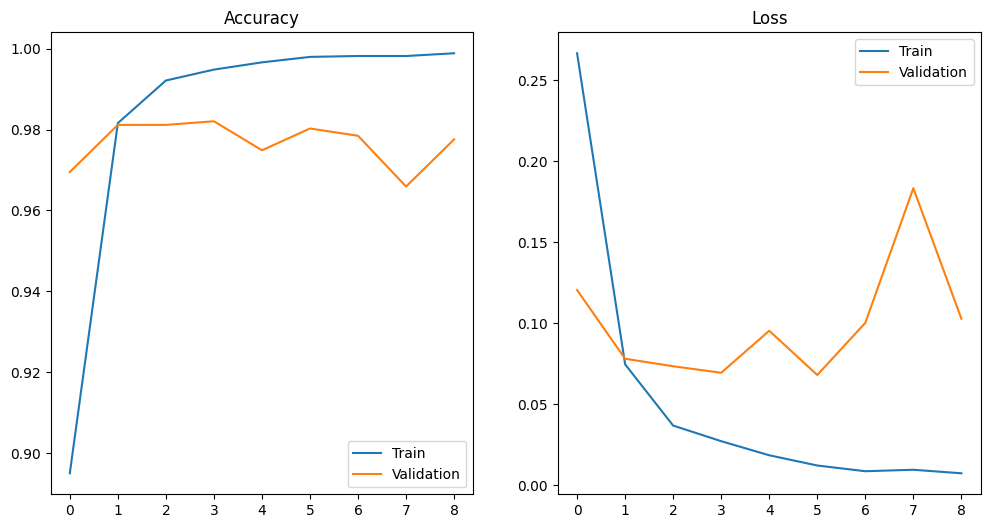

In [41]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")

plt.show()

In [42]:
y_pred = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
y_pred = np.where(y_pred>0.5, 1,0)

In [44]:
ac=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)

print("Accuracy Score: ",ac)
print("F1 Score: ",f1)
print("ROC-AUC Score: ",roc_auc)


Accuracy Score:  0.9802690582959641
F1 Score:  0.9197080291970803
ROC-AUC Score:  0.9486267543342376


In [46]:
lstm_result = pd.DataFrame({
    'Model': ['LSTM'],
    'Accuracy': [ac],
    'F1_score': [f1],
    'Precision': [precision_score(y_test, y_pred)],
    'Recall': [recall_score(y_test, y_pred)],
    'Training_time': [None]
})

In [47]:
lstm_result

,Model,Accuracy,F1_score,Precision,Recall,Training_time
0,LSTM,0.980269,0.919708,0.933333,0.906475,None


In [48]:
result = pd.concat([result,lstm_result],axis=0)

/tmp/ipykernel_24585/1440602602.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result,lstm_result],axis=0)


In [49]:
result.sort_values('Accuracy',ascending=False,inplace = True)

In [50]:
result 

,Model,Accuracy,F1_score,Precision,Recall,Training_time
2,Linear SVM,0.990135,0.959707,0.977612,0.942446,0.009389
3,Random Forest,0.982063,0.922481,1.000000,0.856115,0.855554
0,LSTM,0.980269,0.919708,0.933333,0.906475,NaN
1,Logistic Regression,0.976682,0.898438,0.982906,0.827338,0.014959
0,Naive Bayes,0.964126,0.831933,1.000000,0.712230,0.004876


In [51]:
import joblib

In [53]:
svm_model = saved_models["Linear SVM"]

In [ ]:
joblib.dump(svm_model,'svm_model.pkl')